## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

print('Imports ✅')

Imports ✅


## 1. Chargement & Échantillonnage 

In [3]:
# 1. Charger le dataset
df = pd.read_csv('../Data/RTA Dataset.csv')

# 2. Mélanger tout le dataset
df = df.sample(frac=1, random_state=42)

# 3. Prendre 3000 lignes
df = df.head(3000)

# 4. Preview
print(f'Shape : {df.shape}')
df.head()

Shape : (3000, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
4281,14:27:00,Friday,Over 51,Male,Junior high school,Employee,Above 10yr,NaN,Owner,2-5yrs,...,U-Turn,na,na,na,na,Driver,Normal,Not a Pedestrian,Changing lane to the left,Slight Injury
4010,16:00:00,Sunday,Under 18,Male,Junior high school,Employee,Below 1yr,Automobile,Owner,NaN,...,Other,na,na,na,na,NaN,NaN,Not a Pedestrian,Driving carelessly,Slight Injury
1022,16:56:00,Wednesday,18-30,Male,NaN,NaN,NaN,NaN,NaN,NaN,...,Getting off,Driver or rider,Male,18-30,3,Driver,Normal,Not a Pedestrian,No distancing,Serious Injury
8775,15:48:00,Tuesday,31-50,Male,Junior high school,Employee,Below 1yr,Public (12 seats),Owner,NaN,...,Going straight,Driver or rider,Male,18-30,3,Self-employed,Normal,Not a Pedestrian,Moving Backward,Slight Injury
10000,12:48:00,Friday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,Unknown,...,Going straight,Passenger,Female,31-50,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury


## 2. Prétraitement des Données 

### 2.1 Suppression des doublons

In [6]:
before = len(df)
df = df.drop_duplicates()
print(f'Doublons supprimés : {before - len(df)} lignes')
print(f'Shape après nettoyage : {df.shape}')

Doublons supprimés : 0 lignes
Shape après nettoyage : (3000, 32)


### 2.2 Gestion des valeurs manquantes

In [7]:
# Remplacement des valeurs manquantes catégorielles par le mode
# (sera fait dans le Pipeline scikit-learn — voir section 4)
print('Taux de valeurs manquantes par colonne :')
missing = (df.isnull().sum() / len(df) * 100).round(2)
print(missing[missing > 0].sort_values(ascending=False))

Taux de valeurs manquantes par colonne :
Defect_of_vehicle          34.63
Service_year_of_vehicle    32.07
Work_of_casuality          26.27
Fitness_of_casuality       21.43
Type_of_vehicle             7.90
Types_of_Junction           7.37
Driving_experience          7.07
Educational_level           6.00
Vehicle_driver_relation     4.77
Owner_of_vehicle            3.73
Lanes_or_Medians            3.20
Vehicle_movement            2.93
Area_accident_occured       1.87
Road_surface_type           1.67
Type_of_collision           1.17
Road_allignment             1.03
dtype: float64


### 2.3 Feature Engineering

In [8]:
# Extraction de l'heure depuis la colonne Time
if 'Time' in df.columns:
    df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour
    df['Hour'] = df['Hour'].fillna(df['Hour'].median()).astype(int)
    # Création d'une feature "période de la journée"
    def get_period(h):
        if 6 <= h < 12: return 'Matin'
        elif 12 <= h < 18: return 'Après-midi'
        elif 18 <= h < 22: return 'Soir'
        else: return 'Nuit'
    df['Period_of_day'] = df['Hour'].apply(get_period)
    print('Feature engineering : Hour & Period_of_day créées ✅')

# Suppression de la colonne Time (redondante)
df = df.drop(columns=['Time'], errors='ignore')

print(f'Shape : {df.shape}')

Feature engineering : Hour & Period_of_day créées ✅
Shape : (3000, 33)


### 2.4 Séparation features / cible

In [9]:
TARGET = 'Accident_severity'

# Suppression des colonnes avec trop de NaN (> 50%)
threshold = 0.5
cols_to_drop = [c for c in df.columns if df[c].isnull().mean() > threshold]
print(f'Colonnes supprimées (>{threshold*100}% NaN) : {cols_to_drop}')
df = df.drop(columns=cols_to_drop)

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Encodage de la cible
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)
classes = le_target.classes_

print(f'Classes : {classes}')
print(f'X shape : {X.shape}, y shape : {y_enc.shape}')

Colonnes supprimées (>50.0% NaN) : []
Classes : ['Fatal injury' 'Serious Injury' 'Slight Injury']
X shape : (3000, 32), y shape : (3000,)


### 2.5 Identification des types de colonnes

In [10]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Features numériques ({len(num_features)}) : {num_features}')
print(f'Features catégorielles ({len(cat_features)}) : {cat_features}')

Features numériques (3) : ['Number_of_vehicles_involved', 'Number_of_casualties', 'Hour']
Features catégorielles (29) : ['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Period_of_day']


## 3. Feature Selection

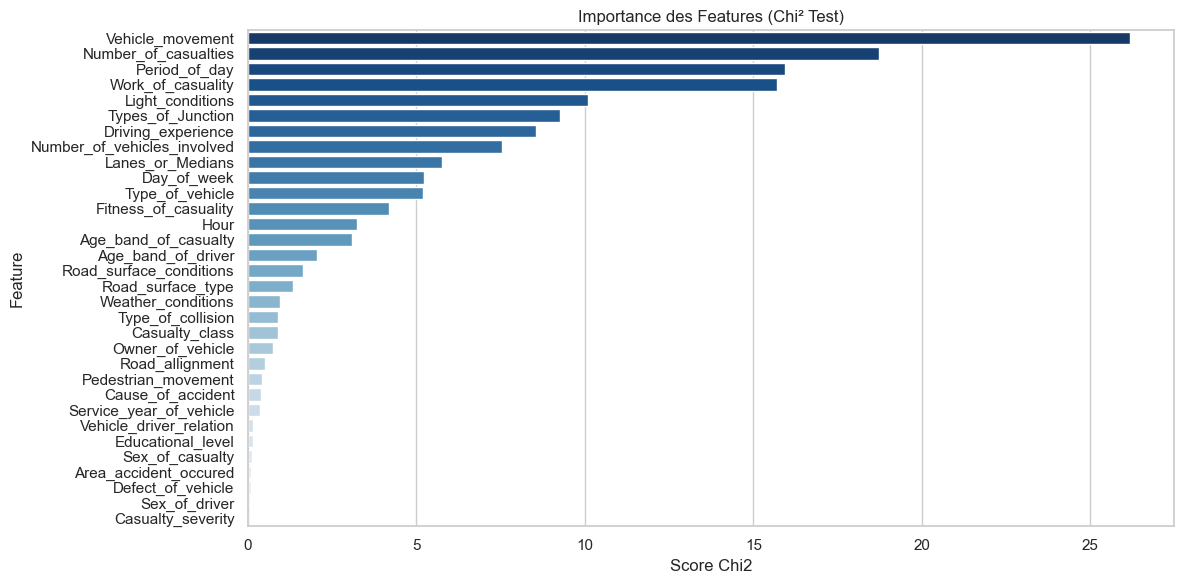


Top 10 features :
                        Feature  Score Chi2
21             Vehicle_movement   26.172171
20         Number_of_casualties   18.714557
31                Period_of_day   15.948927
26            Work_of_casuality   15.706972
16             Light_conditions   10.096496
13            Types_of_Junction    9.259181
5            Driving_experience    8.542570
19  Number_of_vehicles_involved    7.554750
11             Lanes_or_Medians    5.750877
0                   Day_of_week    5.217943


In [11]:
from sklearn.feature_selection import chi2, SelectKBest

# Encodage rapide pour évaluer l'importance des features
X_temp = X.copy()
for col in cat_features:
    le = LabelEncoder()
    X_temp[col] = le.fit_transform(X_temp[col].astype(str))
X_temp = X_temp.fillna(0)

selector = SelectKBest(chi2, k='all')
selector.fit(X_temp.abs(), y_enc)

scores_df = pd.DataFrame({
    'Feature': X.columns,
    'Score Chi2': selector.scores_
}).sort_values('Score Chi2', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=scores_df, x='Score Chi2', y='Feature', palette='Blues_r')
plt.title('Importance des Features (Chi² Test)')
plt.tight_layout()
plt.show()

print('\nTop 10 features :')
print(scores_df.head(10))

## 4. Construction des Pipelines


In [12]:
# Pipeline numérique : imputation + standardisation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline catégoriel : imputation par mode + encodage OHE
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

print('Pipelines construits ✅')

Pipelines construits ✅


## 5. Séparation Train / Test

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)

print(f'Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes')
print(f'Distribution cible (train) : {np.bincount(y_train)}')
print(f'Distribution cible (test)  : {np.bincount(y_test)}')

Train : 2400 lignes | Test : 600 lignes
Distribution cible (train) : [  36  356 2008]
Distribution cible (test)  : [  9  89 502]


## 6. Modélisation — 3 Algorithmes

### 6.1 Régression Logistique (Modèle Linéaire)

In [14]:
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

print(f'[Logistic Regression] Accuracy: {acc_lr:.4f} | F1-Score (weighted): {f1_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=classes))

[Logistic Regression] Accuracy: 0.5167 | F1-Score (weighted): 0.5926

                precision    recall  f1-score   support

  Fatal injury       0.06      0.44      0.11         9
Serious Injury       0.15      0.37      0.21        89
 Slight Injury       0.87      0.54      0.67       502

      accuracy                           0.52       600
     macro avg       0.36      0.45      0.33       600
  weighted avg       0.75      0.52      0.59       600



### 6.2 Arbre de Décision

In [15]:
pipe_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=RANDOM_STATE
    ))
])

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print(f'[Decision Tree] Accuracy: {acc_dt:.4f} | F1-Score (weighted): {f1_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=classes))

[Decision Tree] Accuracy: 0.7700 | F1-Score (weighted): 0.7694

                precision    recall  f1-score   support

  Fatal injury       0.11      0.22      0.14         9
Serious Injury       0.28      0.24      0.25        89
 Slight Injury       0.87      0.87      0.87       502

      accuracy                           0.77       600
     macro avg       0.42      0.44      0.42       600
  weighted avg       0.77      0.77      0.77       600



### 6.3 Random Forest (Modèle Ensembliste)

In [17]:
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f'[Random Forest] Accuracy: {acc_rf:.4f} | F1-Score (weighted): {f1_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=classes))

[Random Forest] Accuracy: 0.8367 | F1-Score (weighted): 0.7623

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00         9
Serious Injury       0.00      0.00      0.00        89
 Slight Injury       0.84      1.00      0.91       502

      accuracy                           0.84       600
     macro avg       0.28      0.33      0.30       600
  weighted avg       0.70      0.84      0.76       600



## 7. Comparaison des Modèles

             Modèle  Accuracy  F1-Score (weighted)
      Decision Tree  0.770000             0.769387
      Random Forest  0.836667             0.762263
Logistic Regression  0.516667             0.592611


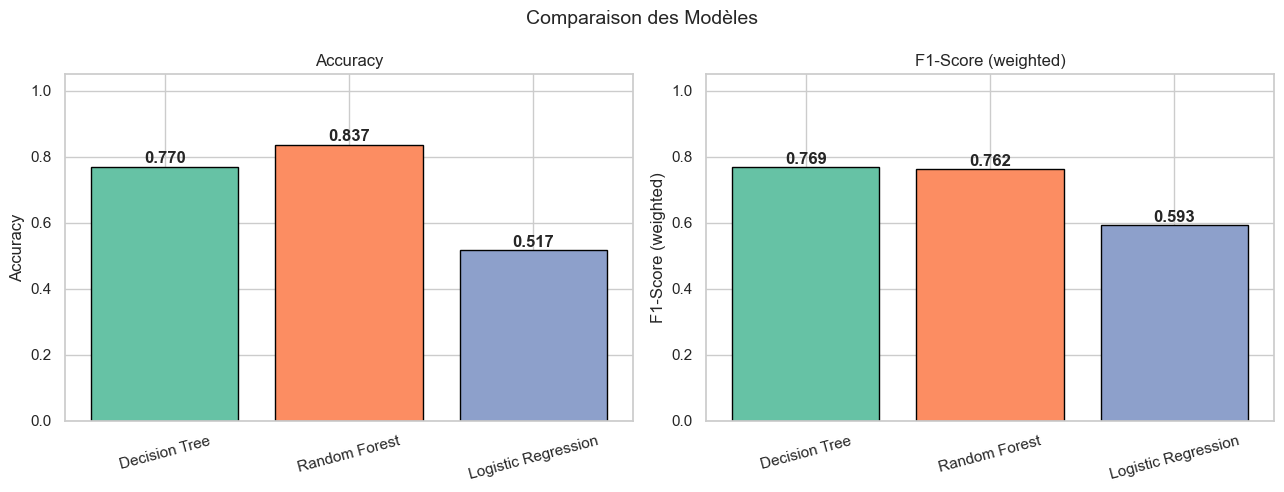

In [18]:
results = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc_lr, acc_dt, acc_rf],
    'F1-Score (weighted)': [f1_lr, f1_dt, f1_rf]
}).sort_values('F1-Score (weighted)', ascending=False)

print(results.to_string(index=False))

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ['Accuracy', 'F1-Score (weighted)']):
    bars = ax.bar(results['Modèle'], results[metric],
                  color=sns.color_palette('Set2', 3), edgecolor='black')
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Comparaison des Modèles', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Matrices de Confusion

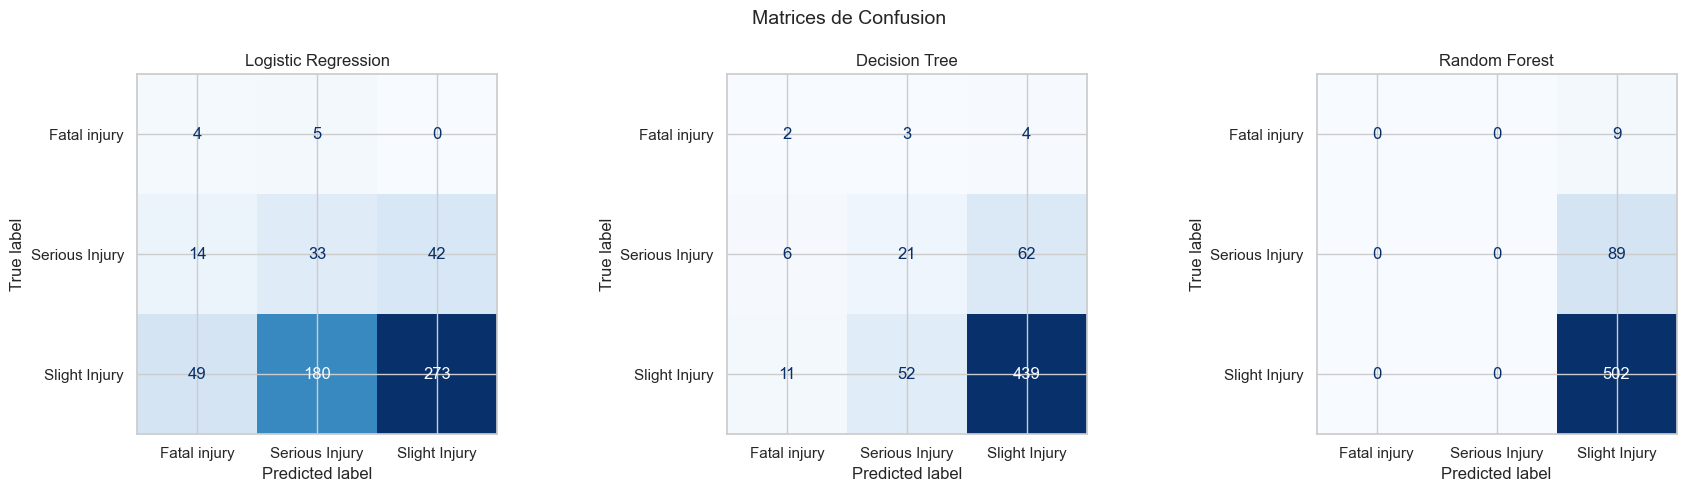

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf)
]

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Matrices de Confusion', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Optimisation du Meilleur Modèle (GridSearchCV)

In [20]:
# Optimisation du Random Forest (meilleur modèle selon F1-Score)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    pipe_rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\nMeilleurs hyperparamètres : {grid_search.best_params_}')
print(f'Meilleur F1-Score CV : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Meilleurs hyperparamètres : {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Meilleur F1-Score CV : 0.7630


In [21]:
# Évaluation du modèle optimisé sur le test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best, average='weighted')

print(f'[Random Forest OPTIMISÉ] Accuracy: {acc_best:.4f} | F1-Score: {f1_best:.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=classes))

[Random Forest OPTIMISÉ] Accuracy: 0.8333 | F1-Score: 0.7637

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00         9
Serious Injury       0.25      0.01      0.02        89
 Slight Injury       0.84      0.99      0.91       502

      accuracy                           0.83       600
     macro avg       0.36      0.34      0.31       600
  weighted avg       0.74      0.83      0.76       600



## 10. Importance des Features (Random Forest)

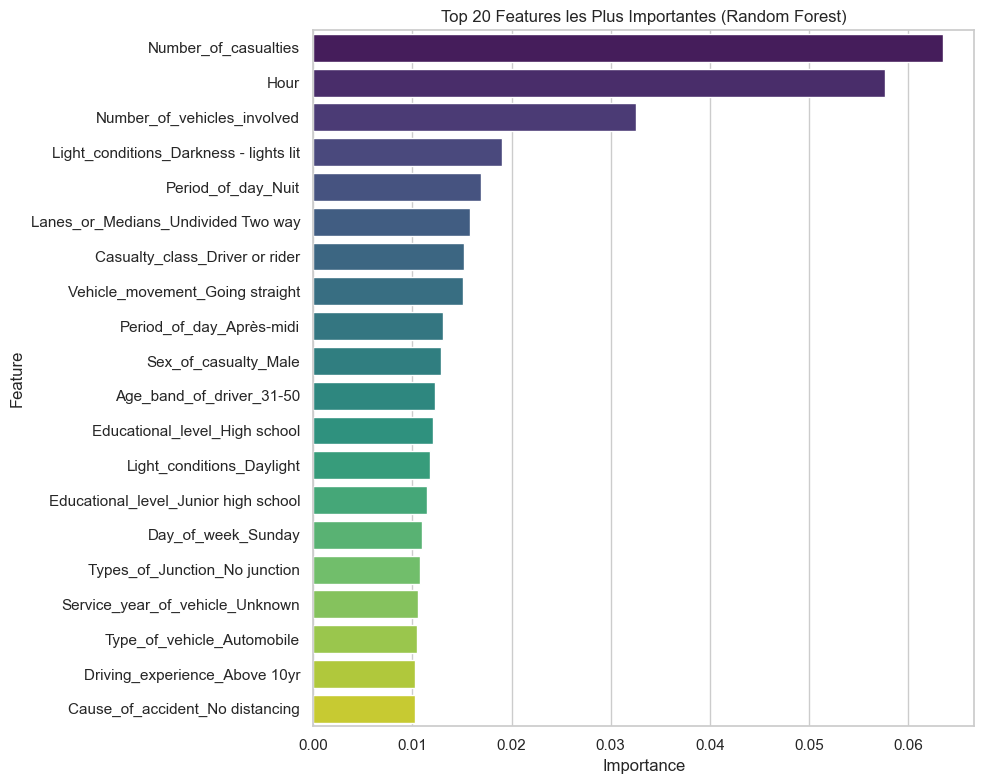

In [22]:
# Récupérer les noms de features après OHE
try:
    ohe_feature_names = best_model.named_steps['preprocessor'] \
        .named_transformers_['cat'] \
        .named_steps['ohe'] \
        .get_feature_names_out(cat_features).tolist()
    all_feature_names = num_features + ohe_feature_names
except Exception:
    all_feature_names = [f'feature_{i}' for i in range(best_model.named_steps['classifier'].n_features_in_)]

importances = best_model.named_steps['classifier'].feature_importances_
feat_imp = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Features les Plus Importantes (Random Forest)')
plt.tight_layout()
plt.show()

## 11. Validation Croisée (Cross-Validation)

Cross-Validation F1-Score (5 folds) :
  Scores     : [np.float64(0.7663), np.float64(0.7766), np.float64(0.7621), np.float64(0.7564), np.float64(0.7564)]
  Moyenne    : 0.7636
  Écart-type : 0.0075


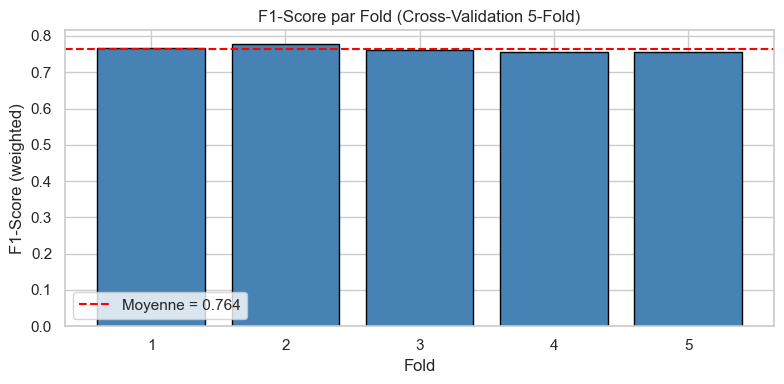

In [23]:
cv_scores = cross_val_score(best_model, X, y_enc, cv=5, scoring='f1_weighted', n_jobs=-1)

print(f'Cross-Validation F1-Score (5 folds) :')
print(f'  Scores     : {[round(s, 4) for s in cv_scores]}')
print(f'  Moyenne    : {cv_scores.mean():.4f}')
print(f'  Écart-type : {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Moyenne = {cv_scores.mean():.3f}')
plt.title('F1-Score par Fold (Cross-Validation 5-Fold)')
plt.xlabel('Fold')
plt.ylabel('F1-Score (weighted)')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Analyse des Erreurs

Nombre d'erreurs : 100 / 600 (16.7%)

Erreurs par classe réelle :
Réel
Serious Injury    88
Fatal injury       9
Slight Injury      3
Name: count, dtype: int64


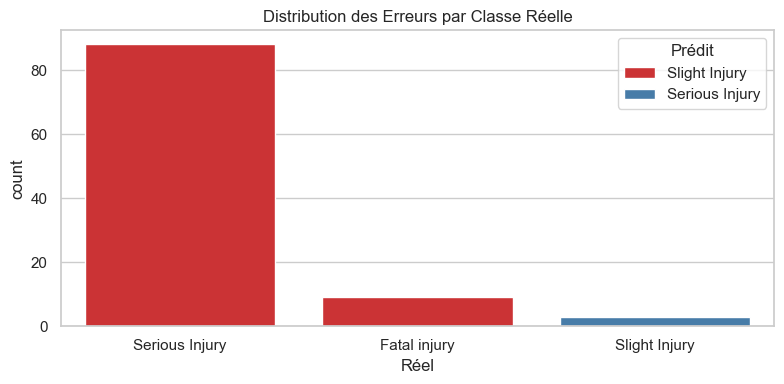

In [24]:
# Identifier les erreurs de prédiction
errors_idx = np.where(y_pred_best != y_test)[0]
print(f'Nombre d\'erreurs : {len(errors_idx)} / {len(y_test)} ({len(errors_idx)/len(y_test)*100:.1f}%)')

# Distribution des erreurs par classe réelle
error_df = pd.DataFrame({
    'Réel': le_target.inverse_transform(y_test[errors_idx]),
    'Prédit': le_target.inverse_transform(y_pred_best[errors_idx])
})

print('\nErreurs par classe réelle :')
print(error_df['Réel'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(data=error_df, x='Réel', hue='Prédit', palette='Set1')
plt.title('Distribution des Erreurs par Classe Réelle')
plt.tight_layout()
plt.show()

## 13. Sauvegarde du Modèle

In [25]:
import joblib
import os

os.makedirs('../src', exist_ok=True)
joblib.dump(best_model, '../src/best_model_rf.pkl')
joblib.dump(le_target, '../src/label_encoder.pkl')

print('Modèle sauvegardé → ../src/best_model_rf.pkl ✅')
print('Label encoder sauvegardé → ../src/label_encoder.pkl ✅')

Modèle sauvegardé → ../src/best_model_rf.pkl ✅
Label encoder sauvegardé → ../src/label_encoder.pkl ✅
